In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\abhin\Dropbox\PC\Downloads\projects\Customer Churn Prediction Platform\data\Telco-Customer-Churn.csv')

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [4]:
df = df.drop("customerID", axis=1)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df_encoded = pd.get_dummies(df, drop_first=True)

In [5]:
df_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


## Train - Test Split

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Train - Model

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

model = LogisticRegression(max_iter=1000, penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42, C=1.0)

pipeline = make_pipeline(StandardScaler(), model)
pipeline.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': pipeline.named_steps['logisticregression'].coef_[0]
})

feature_importance['Abd_Coefficient'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abd_Coefficient', ascending=False).drop(columns='Abd_Coefficient')

print(feature_importance)

scores = cross_validate(
    pipeline,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    n_jobs=-1,
    return_train_score=True
)

c:\Users\abhin\Dropbox\PC\Downloads\projects\Customer Churn Prediction Platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


                                  Feature  Importance
1                                  tenure   -1.427864
3                            TotalCharges    0.686923
25                      Contract_Two year   -0.585914
10            InternetService_Fiber optic    0.469129
24                      Contract_One year   -0.270584
2                          MonthlyCharges   -0.235330
26                   PaperlessBilling_Yes    0.168371
13                     OnlineSecurity_Yes   -0.164808
19                        TechSupport_Yes   -0.154196
28         PaymentMethod_Electronic check    0.145468
9                       MultipleLines_Yes    0.140725
23                    StreamingMovies_Yes    0.136534
21                        StreamingTV_Yes    0.130825
0                           SeniorCitizen    0.078871
6                          Dependents_Yes   -0.069936
7                        PhoneService_Yes   -0.068477
8          MultipleLines_No phone service    0.068477
15                       Onl

In [8]:
print("Logistic Regression per-fold scores:")
for fold, score in enumerate(scores["test_accuracy"], start=1):
    print(f"Fold {fold}: Accuracy = {score:.4f}")

print("\nPrecision per fold:")
for fold, score in enumerate(scores["test_precision"], start=1):
    print(f"Fold {fold}: Precision = {score:.4f}")

print("\nRecall per fold:")
for fold, score in enumerate(scores["test_recall"], start=1):
    print(f"Fold {fold}: Recall = {score:.4f}")

print("\nF1 per fold:")
for fold, score in enumerate(scores["test_f1"], start=1):
    print(f"Fold {fold}: F1 = {score:.4f}")

print("\nTrain accuracy (cross-validated training score):", scores["train_accuracy"].mean())
print("Validation accuracy (cross-validated test score):", scores["test_accuracy"].mean())
print("Std Validation Accuracy:", scores["test_accuracy"].std())

Logistic Regression per-fold scores:
Fold 1: Accuracy = 0.8034
Fold 2: Accuracy = 0.8112
Fold 3: Accuracy = 0.7899
Fold 4: Accuracy = 0.8111
Fold 5: Accuracy = 0.8040

Precision per fold:
Fold 1: Precision = 0.6540
Fold 2: Precision = 0.6636
Fold 3: Precision = 0.6250
Fold 4: Precision = 0.6677
Fold 5: Precision = 0.6633

Recall per fold:
Fold 1: Recall = 0.5508
Fold 2: Recall = 0.5856
Fold 3: Recall = 0.5214
Fold 4: Recall = 0.5710
Fold 5: Recall = 0.5321

F1 per fold:
Fold 1: F1 = 0.5980
Fold 2: F1 = 0.6222
Fold 3: F1 = 0.5685
Fold 4: F1 = 0.6156
Fold 5: F1 = 0.5905

Train accuracy (cross-validated training score): 0.8064035663809441
Validation accuracy (cross-validated test score): 0.8039198093425381
Std Validation Accuracy: 0.0077545962988231475


## Evaluation

In [9]:
y_pred = model.predict(X_test_scaled)

NameError: name 'X_test_scaled' is not defined

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8055358410220014
Precision: 0.65527950310559
Recall: 0.5641711229946524
F1: 0.6063218390804598
[[924 111]
 [163 211]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
coef = pd.DataFrame({'coefficient': model.coef_[0], 'feature': X_train.columns})

coef.sort_values(by='coefficient', ascending=False, inplace=True)

In [ ]:
coef

,coefficient,feature
10,0.776154,InternetService_Fiber optic
3,0.514285,TotalCharges
23,0.257227,StreamingMovies_Yes
21,0.257144,StreamingTV_Yes
9,0.216167,MultipleLines_Yes
26,0.182034,PaperlessBilling_Yes
28,0.181103,PaymentMethod_Electronic check
0,0.053073,SeniorCitizen
17,0.053048,DeviceProtection_Yes
29,0.032262,PaymentMethod_Mailed check


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, random_state=42)
# rf.fit(X_train_scaled, y_train)

rf_scores = cross_validate(rf, X, y, cv=5, scoring=['accuracy','precision','recall','f1'],
                          n_jobs=-1, return_train_score=True)

In [11]:
print("Random Forest")
print("Train accuracy:", rf_scores["train_accuracy"].mean())
print("Validation accuracy:", rf_scores["test_accuracy"].mean())
print("Std Validation Accuracy:", rf_scores["test_accuracy"].std())

print("\nAccuracy:", rf_scores["test_accuracy"].mean())
print("Precision:", rf_scores["test_precision"].mean())
print("Recall:", rf_scores["test_recall"].mean())
print("F1 Score:", rf_scores["test_f1"].mean())

Random Forest
Train accuracy: 0.9978702257399696
Validation accuracy: 0.7910004274469321
Std Validation Accuracy: 0.01094951113892563

Accuracy: 0.7910004274469321
Precision: 0.641070343433165
Recall: 0.48635718484322804
F1 Score: 0.5528121196790542


In [12]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Train Accuracy", "Validation Accuracy", "Precision", "Recall", "F1"],
    "Logistic Regression": [
        scores["train_accuracy"].mean(),
        scores["test_accuracy"].mean(),
        scores["test_precision"].mean(),
        scores["test_recall"].mean(),
        scores["test_f1"].mean()
    ],
    "Random Forest": [
        rf_scores["train_accuracy"].mean(),
        rf_scores["test_accuracy"].mean(),
        rf_scores["test_precision"].mean(),
        rf_scores["test_recall"].mean(),
        rf_scores["test_f1"].mean()
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Train Accuracy,0.806404,0.997870
1,Validation Accuracy,0.803920,0.791000
2,Precision,0.654730,0.641070
3,Recall,0.552177,0.486357
4,F1,0.598950,0.552812


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.7920511000709723
Precision: 0.6431095406360424
Recall: 0.48663101604278075
F1: 0.5540334855403348
[[934 101]
 [192 182]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



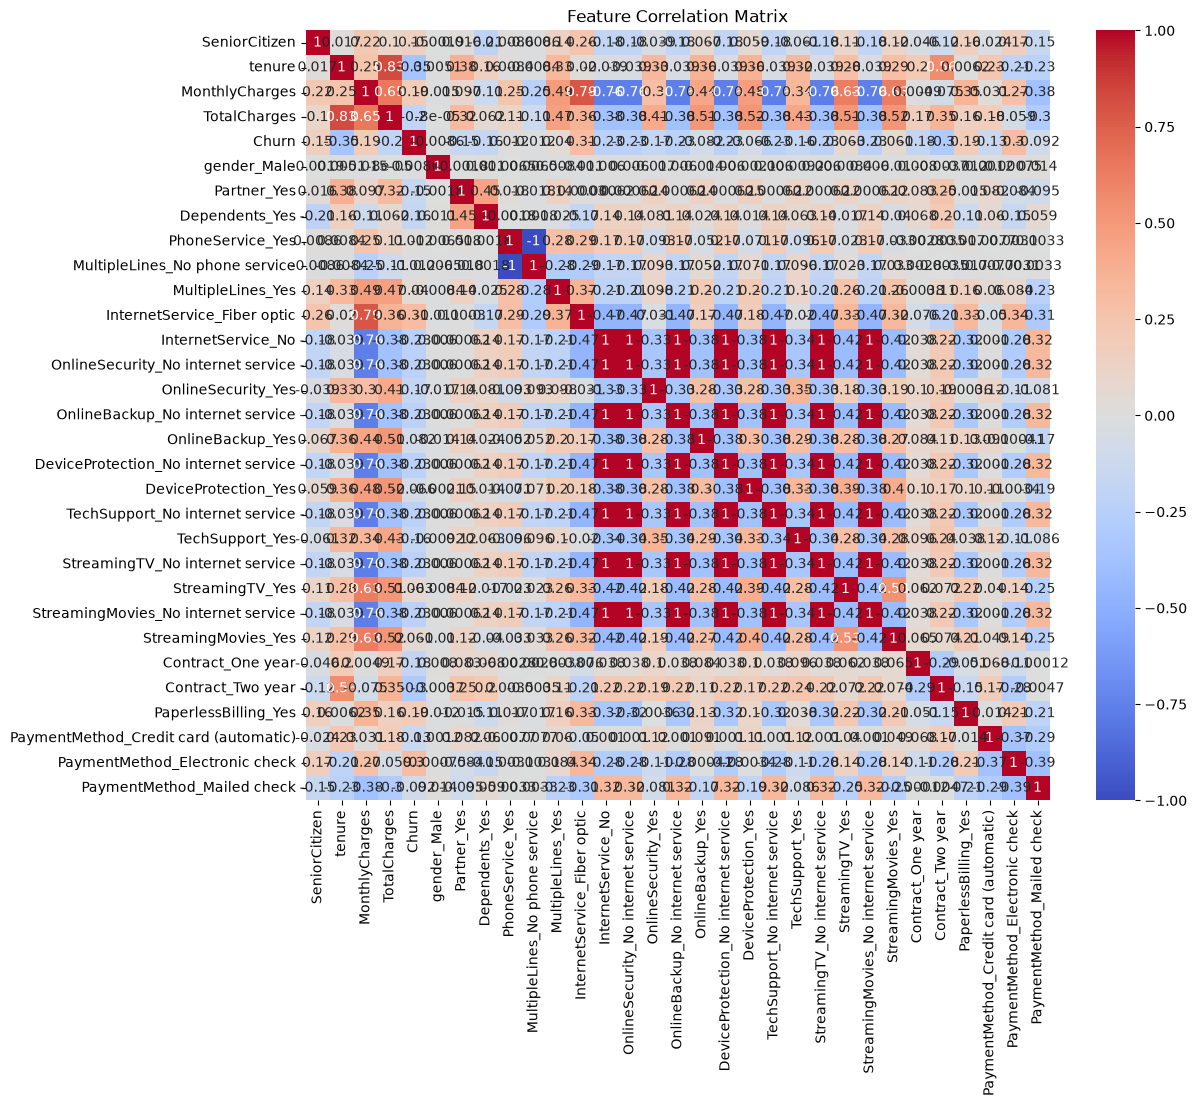

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

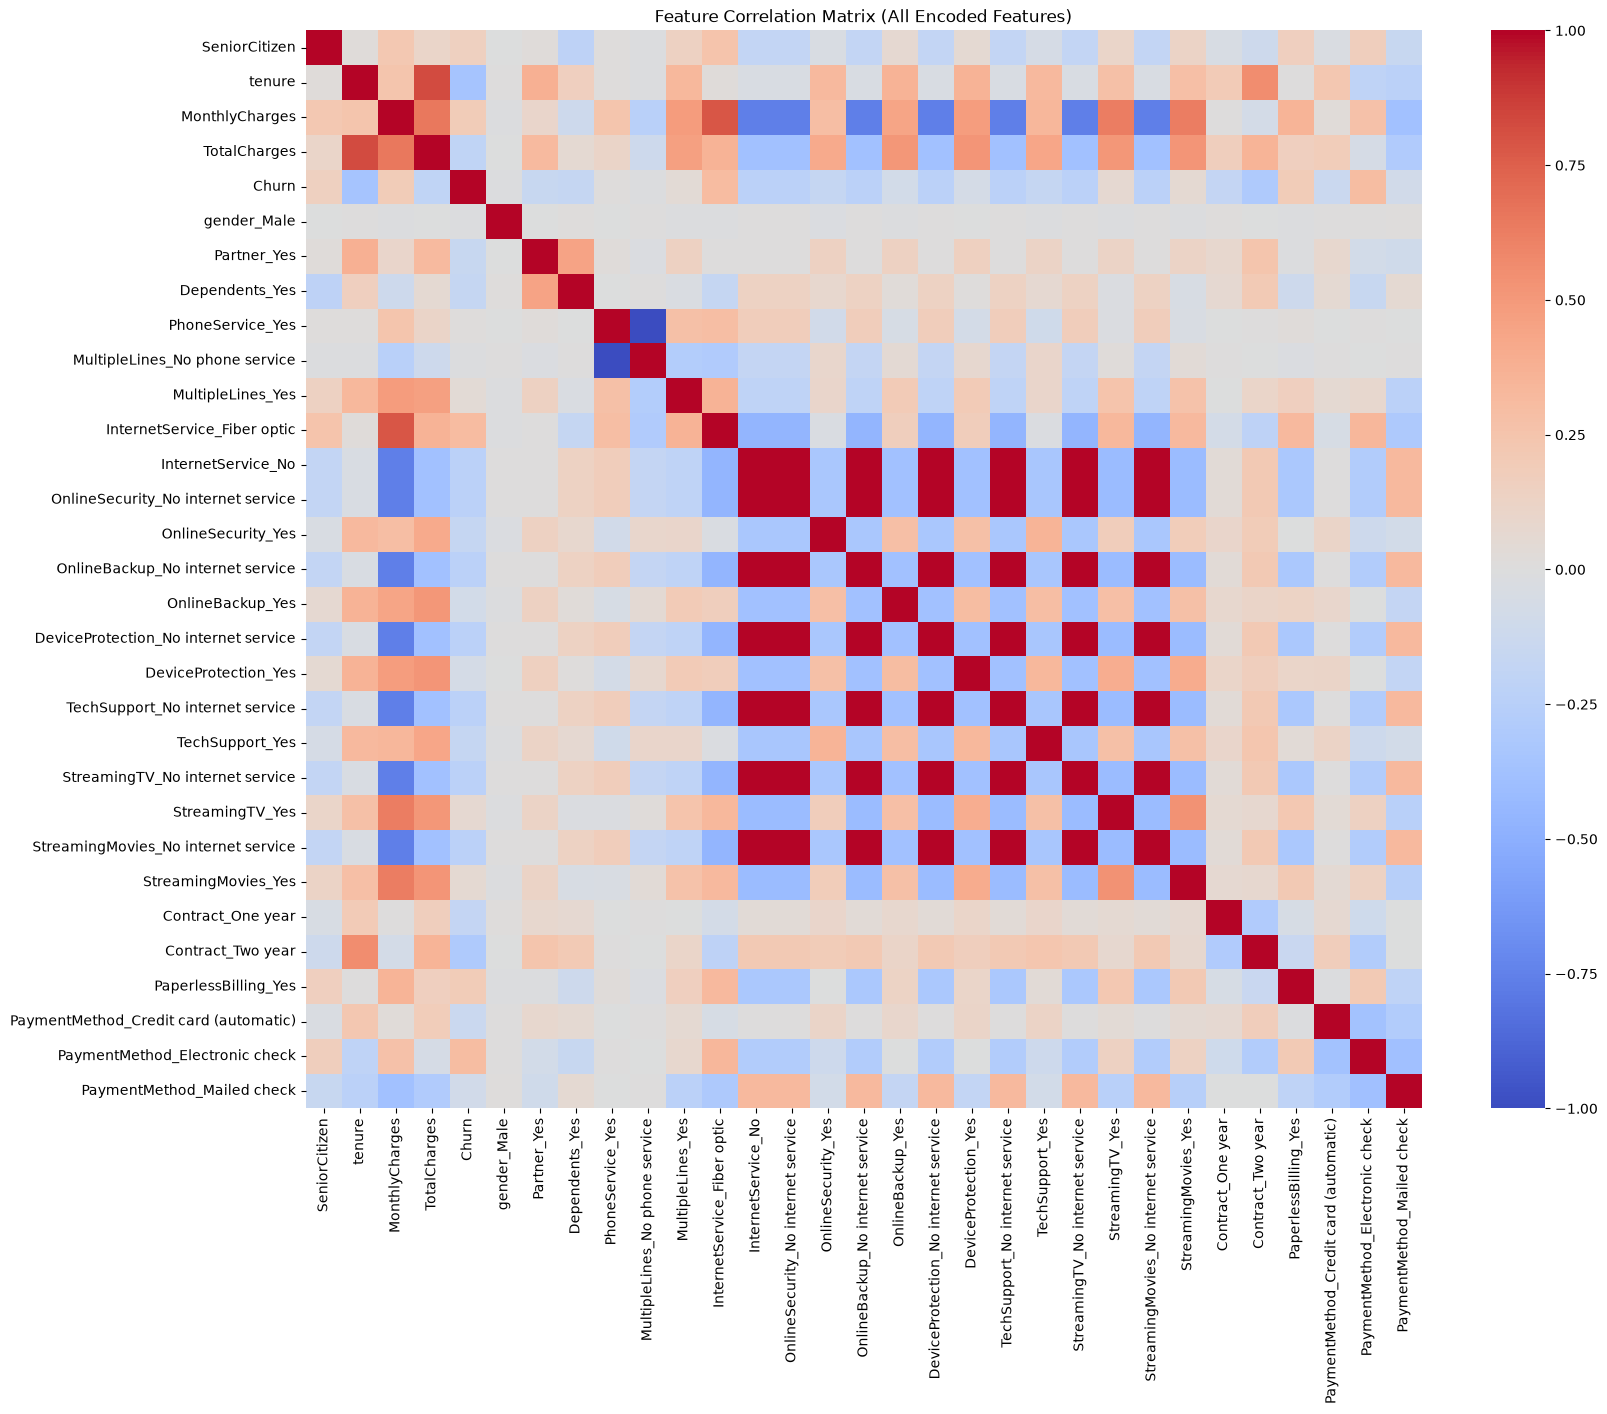

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (All Encoded Features)')
plt.show()

In [13]:
df[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


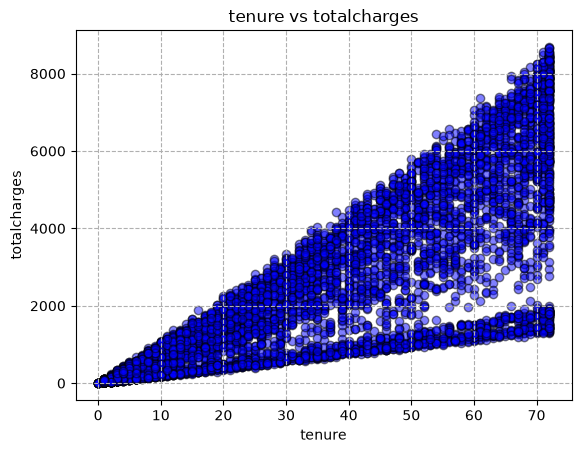

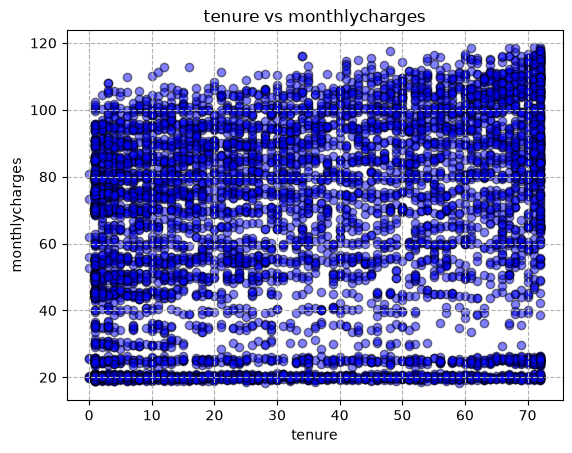

In [20]:
import matplotlib.pyplot as plt
plt.scatter(df['tenure'], df['TotalCharges'], color = 'blue', alpha = 0.5, edgecolors='black')
plt.title('tenure vs totalcharges')
plt.xlabel('tenure')
plt.ylabel('totalcharges')

plt.grid(True, linestyle='--')
plt.show()

plt.scatter(df['tenure'], df['MonthlyCharges'], color = 'blue', alpha = 0.5, edgecolors='black')
plt.title('tenure vs monthlycharges')
plt.xlabel('tenure')
plt.ylabel('monthlycharges')

plt.grid(True, linestyle='--')
plt.show()

In [21]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state = 42)
# 4. View results
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
print(mi_df.sort_values(by='MI_Score', ascending=False))

                                  Feature  MI_Score
1                                  tenure  0.075548
25                      Contract_Two year  0.067045
10            InternetService_Fiber optic  0.053481
2                          MonthlyCharges  0.049610
12     OnlineSecurity_No internet service  0.044575
3                            TotalCharges  0.043600
28         PaymentMethod_Electronic check  0.043210
11                     InternetService_No  0.033875
20        StreamingTV_No internet service  0.033730
22    StreamingMovies_No internet service  0.032607
14       OnlineBackup_No internet service  0.030464
18        TechSupport_No internet service  0.029420
16   DeviceProtection_No internet service  0.025713
6                          Dependents_Yes  0.021981
26                   PaperlessBilling_Yes  0.020925
24                      Contract_One year  0.019612
0                           SeniorCitizen  0.019532
5                             Partner_Yes  0.014714
13          

In [25]:
X['AverageMonthlySpend'] = X['TotalCharges']/(X['tenure']+1)
X['NewCustomer'] = X['tenure'] < 12
X['LongTermCustomer'] = X['tenure'] >= 24
X['HighMonthlyCharges'] = X['MonthlyCharges'] > X['MonthlyCharges'].median()

In [26]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AverageMonthlySpend,NewCustomer,LongTermCustomer,HighMonthlyCharges
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,True,False,True,False,14.925000,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,True,False,False,False,False,True,53.985714,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,True,False,False,True,36.050000,True,False,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,True,False,False,False,False,False,40.016304,False,True,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,True,False,True,False,50.550000,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,True,False,True,False,False,True,79.620000,False,True,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,True,False,True,True,False,False,100.861644,False,True,True
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,True,False,True,False,28.870833,True,False,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,True,False,False,True,61.320000,True,False,True


c:\Users\abhin\Dropbox\PC\Downloads\projects\Customer Churn Prediction Platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


                                  Feature  Importance
30                    AverageMonthlySpend   -1.043040
1                                  tenure   -1.009145
10            InternetService_Fiber optic    0.743336
25                      Contract_Two year   -0.703056
3                            TotalCharges    0.570054
24                      Contract_One year   -0.294060
23                    StreamingMovies_Yes    0.272682
21                        StreamingTV_Yes    0.260334
9                       MultipleLines_Yes    0.233587
26                   PaperlessBilling_Yes    0.168552
28         PaymentMethod_Electronic check    0.125228
13                     OnlineSecurity_Yes   -0.093780
20        StreamingTV_No internet service   -0.080733
18        TechSupport_No internet service   -0.080733
12     OnlineSecurity_No internet service   -0.080733
11                     InternetService_No   -0.080733
16   DeviceProtection_No internet service   -0.080733
14       OnlineBackup_No int

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [30]:
y_pred = model.predict(X_test_scaled)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8055358410220014
Precision: 0.65527950310559
Recall: 0.5641711229946524
F1: 0.6063218390804598
[[924 111]
 [163 211]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

